In [50]:
import polars as pl

from src.data import (
    extract_storms,
    read_era5_data,
    read_fetch,
    read_weather_data,
)
from src.figs import create_qq_plot, create_wind_rose

In [2]:
closest, latest = await read_weather_data()

In [3]:
hourly_era5, monthly_era5 = await read_era5_data(
    closest["datetime"].min(), latest["datetime"].max()
)

In [56]:
read_fetch()

NameError: name 'rasterio' is not defined

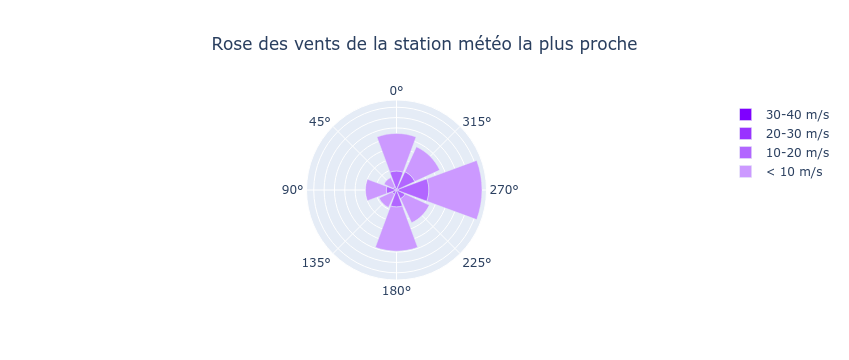

In [6]:
create_wind_rose(
    closest, title="Rose des vents de la station météo la plus proche"
)

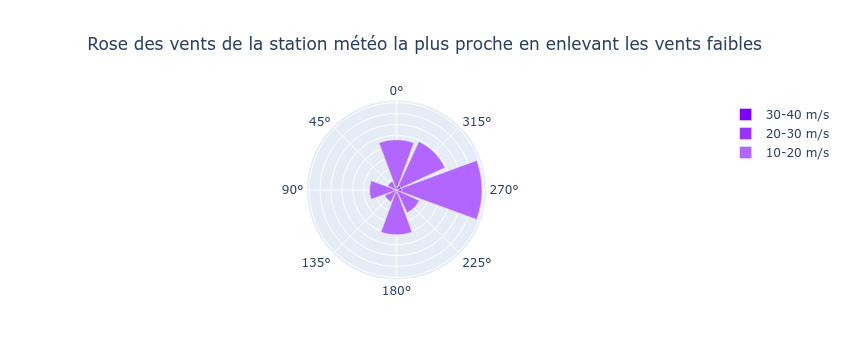

In [13]:
create_wind_rose(
    closest,
    title="Rose des vents de la station météo la plus proche en enlevant les vents faibles",
    filter_low_winds=True,
)

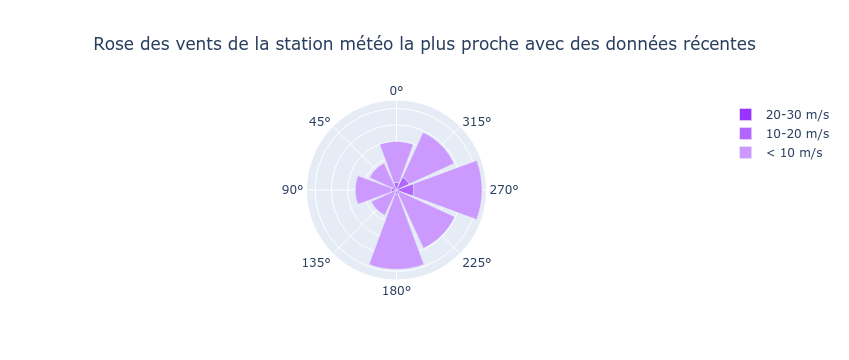

In [15]:
create_wind_rose(
    latest,
    title="Rose des vents de la station météo la plus proche avec des données récentes",
)

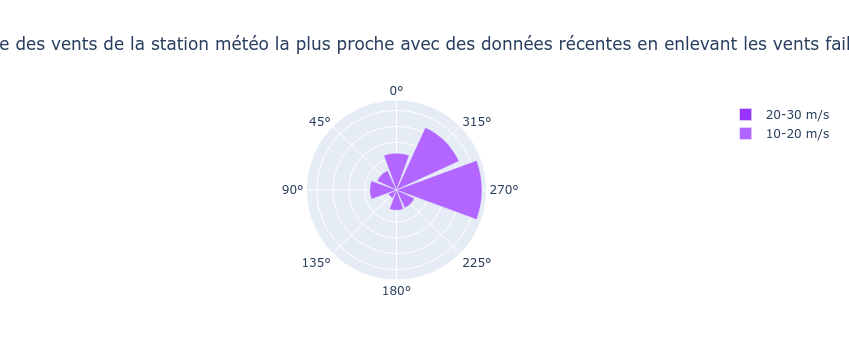

In [14]:
create_wind_rose(
    latest,
    title="Rose des vents de la station météo la plus proche avec des données récentes en enlevant les vents faibles",
    filter_low_winds=True,
)

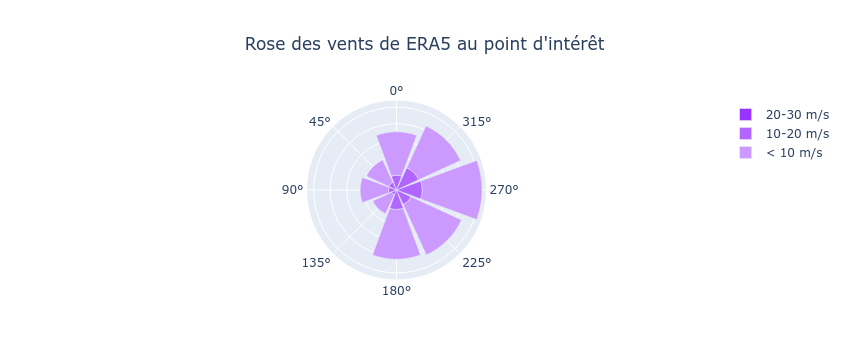

In [9]:
create_wind_rose(
    hourly_era5,
    title="Rose des vents de ERA5 au point d'intérêt",
)

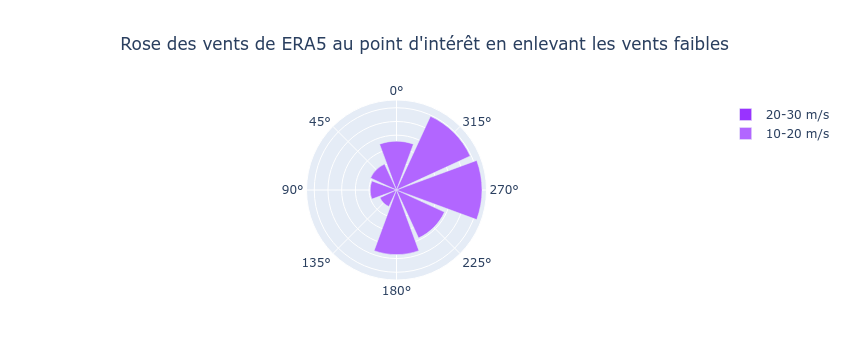

In [16]:
create_wind_rose(
    hourly_era5,
    title="Rose des vents de ERA5 au point d'intérêt en enlevant les vents faibleskkk",
    filter_low_winds=True,
)

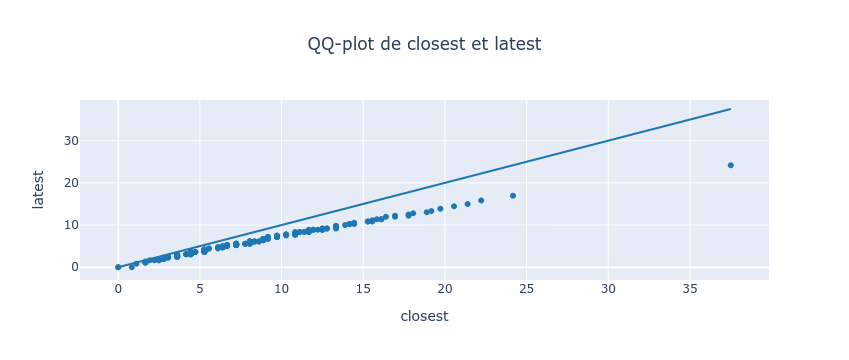

In [42]:
create_qq_plot(
    closest["wind_speed"].alias("closest"),
    latest["wind_speed"].alias("latest"),
)

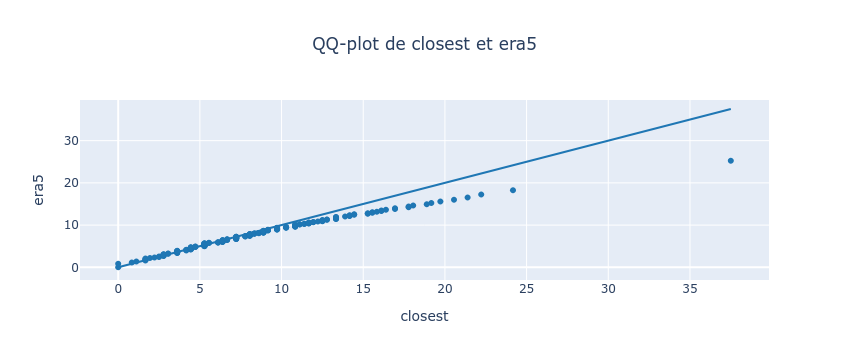

In [43]:
create_qq_plot(
    closest["wind_speed"].alias("closest"),
    hourly_era5["wind_speed"].alias("era5"),
)

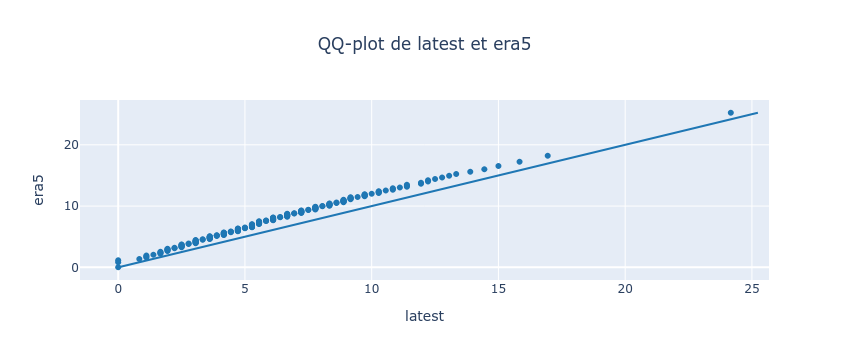

In [41]:
create_qq_plot(
    latest["wind_speed"].alias("latest"),
    hourly_era5["wind_speed"].alias("era5"),
)

In [45]:
latest_storms = extract_storms(latest, threshold=15)
era5_storms = extract_storms(hourly_era5, threshold=15)

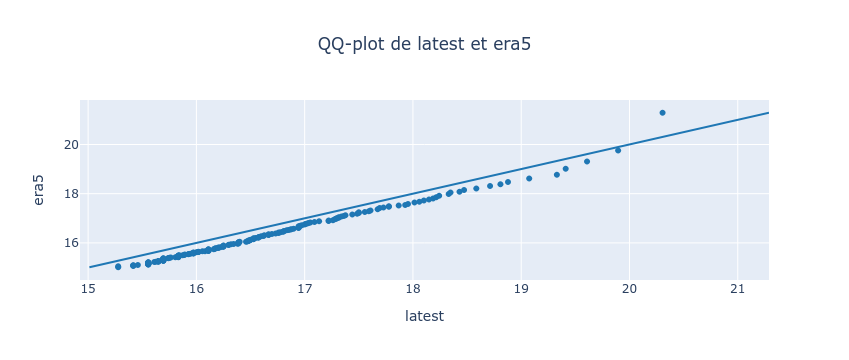

In [46]:
create_qq_plot(
    latest_storms["wind_speed_mean"].alias("latest"),
    era5_storms["wind_speed_mean"].alias("era5"),
)

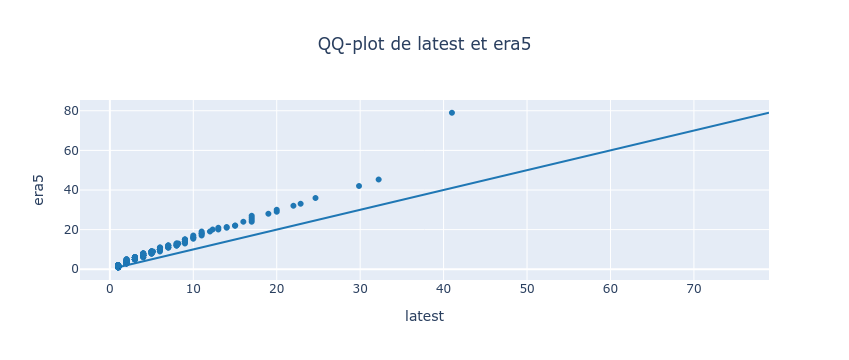

In [47]:
create_qq_plot(
    latest_storms["duration"].alias("latest"),
    era5_storms["duration"].alias("era5"),
)